### CONEXION DDBB OLIST

In [1]:

from sqlalchemy import create_engine, text
import ssl

## CONEXION BBDD MYSQL ##
DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

# Crear engine apuntando a la base 'olist'
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}} 
)

# tablas 'olist'
with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()
    tables = [row[0] for row in tables]   # convertir a lista simple de strings
    
    print("Tablas en la base 'olist':")
    for t in tables:
        print("-", t)



Tablas en la base 'olist':
- dash_olist_categorias_resumen
- dash_olist_demorados
- dash_olist_sellers
- dash_olist_states
- dash_olist_ventas_meses
- dash_sentiment_analysis
- distribucion_pedidos
- olist_customers_dataset
- olist_geolocation_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset
- pedidos_por_tiempo
- product_category_name_translation


In [11]:
# =====================================================
# Análisis de ventas OLIST (2017 - 2018)
# =====================================================

import pandas as pd
from IPython.display import display, Markdown

# Cargar datos desde SQL con varios JOIN
query = """
SELECT 
    pct.product_category_name_english AS product_category_name,
    i.price,
    i.seller_id,
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp,
    r.review_score
FROM olist_order_items_dataset i
LEFT JOIN olist_products_dataset p
    ON i.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
LEFT JOIN olist_orders_dataset o
    ON i.order_id = o.order_id
LEFT JOIN olist_customers_dataset c
    ON o.customer_id = c.customer_id
LEFT JOIN olist_order_reviews_dataset r
    ON o.order_id = r.order_id
WHERE o.order_status <> 'canceled'
"""
df = pd.read_sql_query(query, con=engine)

# Preparación de los datos
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["order_year"] = df["order_purchase_timestamp"].dt.year
df = df[df["order_year"].isin([2017, 2018])]

# Total de ventas por año y categoría
ventas_anuales = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(total_sales=("price", "sum"))
      .reset_index()
)

# Vendedores únicos
sellers_anuales = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(unique_sellers=("seller_id", "nunique"))
      .reset_index()
)

# Clientes únicos
customers_anuales = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(customers=("customer_unique_id", "nunique"))
      .reset_index()
)

# Clientes recurrentes
repeat_customers = (
    df.groupby(["product_category_name", "order_year", "customer_unique_id"])
      .agg(order_count=("order_id", "nunique"))
      .reset_index()
)

# Filtro los clientes con más de un pedido
repeat_customers = (
    repeat_customers[repeat_customers["order_count"] > 1]
      .groupby(["product_category_name", "order_year"])
      .agg(repeat_customers=("customer_unique_id", "nunique"))
      .reset_index()
)

# Promedio de review_score
avg_scores = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(avg_score=("review_score", "mean"))
      .reset_index()
)

# Número de pedidos
orders_qty = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(orders_qty=("order_id", "nunique"))
      .reset_index()
)

# Tablas pivotadas
pivot_sales = ventas_anuales.pivot(index="product_category_name", columns="order_year", values="total_sales").fillna(0).reset_index()
pivot_sellers = sellers_anuales.pivot(index="product_category_name", columns="order_year", values="unique_sellers").fillna(0).astype(int).reset_index()
pivot_customers = customers_anuales.pivot(index="product_category_name", columns="order_year", values="customers").fillna(0).astype(int).reset_index()
pivot_repeat = repeat_customers.pivot(index="product_category_name", columns="order_year", values="repeat_customers").fillna(0).astype(int).reset_index()
pivot_scores = avg_scores.pivot(index="product_category_name", columns="order_year", values="avg_score").fillna(0).round(2).reset_index()
pivot_orders = orders_qty.pivot(index="product_category_name", columns="order_year", values="orders_qty").fillna(0).astype(int).reset_index()

# Renombrar columnas por año
rename_map = {2017: "_2017", 2018: "_2018"}

# Bucle para cambiar nombres
for pivot, prefix in [
    (pivot_sales, "TotalSales"),
    (pivot_sellers, "UniqueSellers"),
    (pivot_customers, "Customers"),
    (pivot_repeat, "RepeatCustomers"),
    (pivot_scores, "avg_score"),
    (pivot_orders, "OrdersQty")
]:
    for year, suffix in rename_map.items():
        if year in pivot.columns:
            pivot.rename(columns={year: f"{prefix}{suffix}"}, inplace=True)

# Combinar todas las tablas
merged_df = pivot_sales
merged_df = merged_df.merge(pivot_sellers, on="product_category_name", how="left")
merged_df = merged_df.merge(pivot_customers, on="product_category_name", how="left")
merged_df = merged_df.merge(pivot_repeat, on="product_category_name", how="left")
merged_df = merged_df.merge(pivot_scores, on="product_category_name", how="left")
merged_df = merged_df.merge(pivot_orders, on="product_category_name", how="left")

# Variación porcentual de ventas
merged_df["delta_sales_pct_2017_2018"] = (
    ((merged_df["TotalSales_2018"] - merged_df["TotalSales_2017"]) /
     merged_df["TotalSales_2017"].replace(0, pd.NA)) * 100
).round(2)

# Ordenar resultados
merged_df = merged_df.sort_values(by="TotalSales_2018", ascending=False)

# Mostrar resultados
display(Markdown("#### Ventas, clientes, pedidos y valoración media por categoría (2017 - 2018)"))
display(
    merged_df[
        [
            "product_category_name",
            "TotalSales_2017",
            "TotalSales_2018",
            "delta_sales_pct_2017_2018",
            "OrdersQty_2017",
            "OrdersQty_2018",
            "UniqueSellers_2017",
            "UniqueSellers_2018",
            "Customers_2017",
            "Customers_2018",
            "RepeatCustomers_2017",
            "RepeatCustomers_2018",
            "avg_score_2017",
            "avg_score_2018"
        ]
    ].head(20)
)


#### Ventas, clientes, pedidos y valoración media por categoría (2017 - 2018)

order_year,product_category_name,TotalSales_2017,TotalSales_2018,delta_sales_pct_2017_2018,OrdersQty_2017,OrdersQty_2018,UniqueSellers_2017,UniqueSellers_2018,Customers_2017,Customers_2018,RepeatCustomers_2017,RepeatCustomers_2018,avg_score_2017,avg_score_2018
44,health_beauty,481142.73,770002.81,60.04,3382,5375,236,393,3297,5315,82.0,57.0,4.00,4.12
71,watches_gifts,486519.02,708305.95,45.59,2114,3485,58,76,2095,3442,18.0,38.0,3.33,4.00
8,bed_bath_table,497970.94,537514.13,7.94,4496,4898,104,160,4346,4808,139.0,89.0,3.87,3.36
66,sports_leisure,447546.59,530182.18,18.46,3621,4035,285,366,3517,3960,95.0,69.0,2.80,4.21
16,computers_accessories,400490.61,502432.09,25.45,2606,4030,176,206,2567,3957,37.0,70.0,5.00,4.75
50,housewares,227850.67,397688.06,74.54,2439,3399,228,364,2417,3365,20.0,34.0,4.29,2.92
40,furniture_decor,336272.26,385312.01,14.58,3187,3186,246,239,3113,3136,72.0,50.0,5.00,3.64
6,auto,238545.04,346632.44,45.31,1415,2448,179,285,1398,2426,17.0,22.0,5.00,0.00
7,baby,152854.33,256086.70,67.54,1203,1656,110,193,1192,1643,11.0,12.0,3.80,3.00
21,cool_stuff,388971.98,230752.41,-40.68,2200,1409,183,164,2195,1401,5.0,8.0,2.40,5.00


In [19]:
# =====================================================
# Top 10 categorías por ventas 2018 con crecimiento y ratio
# =====================================================

# Seleccionar las 10 categorías con más ventas en 2018
top10_sales_2018 = merged_df.sort_values(by="TotalSales_2018", ascending=False).head(10)

# Crear nuevo DataFrame con las columnas necesarias
growth_df = top10_sales_2018[[
    "product_category_name",
    "UniqueSellers_2017",
    "UniqueSellers_2018",
    "OrdersQty_2017",
    "OrdersQty_2018"
]].copy()

# Calcular crecimiento porcentual de vendedores
growth_df["sellers_growth_pct"] = (
    ((growth_df["UniqueSellers_2018"] - growth_df["UniqueSellers_2017"]) /
     growth_df["UniqueSellers_2017"].replace(0, pd.NA)) * 100
).round(2)

# Calcular crecimiento porcentual de pedidos
growth_df["orders_growth_pct"] = (
    ((growth_df["OrdersQty_2018"] - growth_df["OrdersQty_2017"]) /
     growth_df["OrdersQty_2017"].replace(0, pd.NA)) * 100
).round(2)

# Calcular ratio entre el crecimiento de sellers y el de pedidos
growth_df["ratio_growth_sellers_orders"] = (
    growth_df["sellers_growth_pct"] / growth_df["orders_growth_pct"]
).round(2)

# Ordenar por crecimiento de pedidos
growth_df = growth_df.sort_values(by="orders_growth_pct", ascending=False)

# Mostrar resultados
display(Markdown("#### Top 10 categorías por ventas 2018 — crecimiento y ratio sellers/orders"))
display(
    growth_df[[
        "product_category_name",
        "sellers_growth_pct",
        "orders_growth_pct",
        "ratio_growth_sellers_orders"
    ]]
)


#### Top 10 categorías por ventas 2018 — crecimiento y ratio sellers/orders

order_year,product_category_name,sellers_growth_pct,orders_growth_pct,ratio_growth_sellers_orders
6,auto,59.22,73.00,0.81
71,watches_gifts,31.03,64.85,0.48
44,health_beauty,66.53,58.93,1.13
16,computers_accessories,17.05,54.64,0.31
50,housewares,59.65,39.36,1.52
7,baby,75.45,37.66,2.00
66,sports_leisure,28.42,11.43,2.49
8,bed_bath_table,53.85,8.94,6.02
40,furniture_decor,-2.85,-0.03,95.00
21,cool_stuff,-10.38,-35.95,0.29


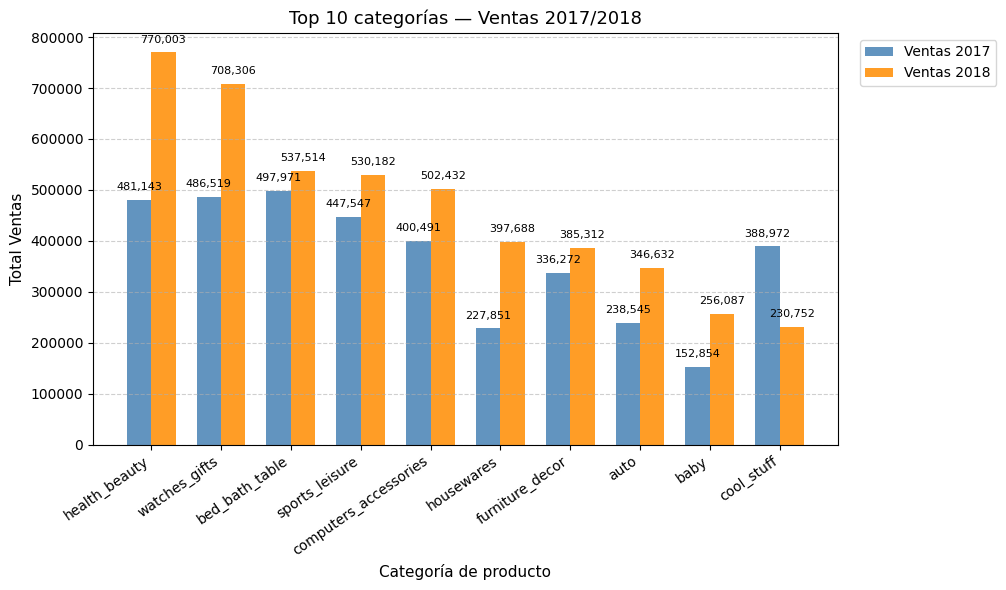

In [18]:
# Filtrar las 10 categorías con mayores ventas en 2018
top10_df = merged_df.sort_values(by="TotalSales_2018", ascending=False).head(10)

# Preparar los datos para el gráfico
categories = top10_df["product_category_name"]
sales_2017 = top10_df["TotalSales_2017"]
sales_2018 = top10_df["TotalSales_2018"]

# Posiciones para las barras
x = np.arange(len(categories))
width = 0.35

# Crear figura y ejes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para 2017 y 2018
bars1 = ax1.bar(x - width/2, sales_2017, width, label="Ventas 2017", color="steelblue", alpha=0.85)
bars2 = ax1.bar(x + width/2, sales_2018, width, label="Ventas 2018", color="darkorange", alpha=0.85)

# Etiquetas de valor encima de las barras
max_height = max(sales_2017.max(), sales_2018.max())
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            height + (0.02 * max_height),
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Personalización del gráfico
ax1.set_title("Top 10 categorías — Ventas 2017/2018", fontsize=13)
ax1.set_xlabel("Categoría de producto", fontsize=11)
ax1.set_ylabel("Total Ventas", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=35, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.6)
ax1.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

# Ajuste de diseño para evitar cortes
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Mostrar gráfico
plt.show()


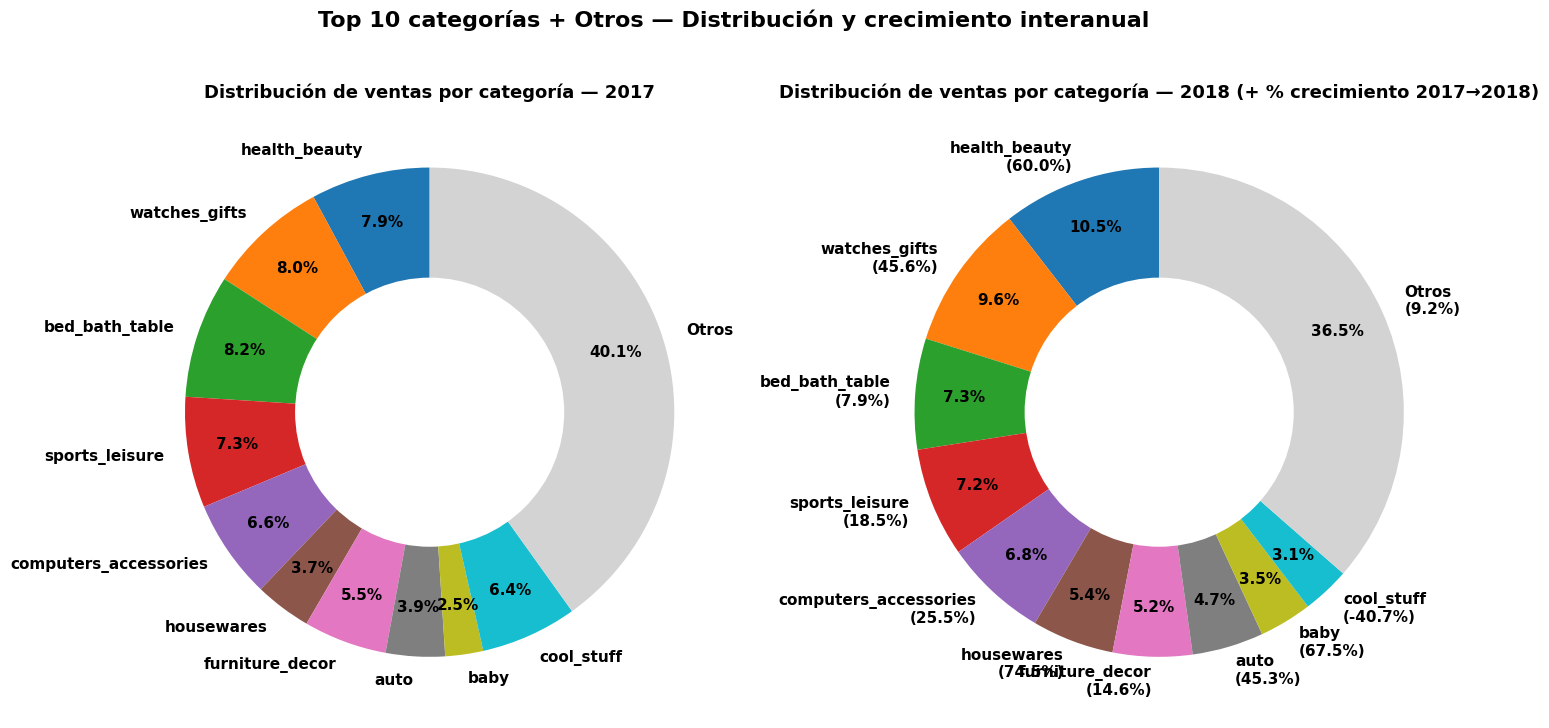

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Calcular las ventas totales por categoría
total_sales = merged_df[["product_category_name", "TotalSales_2017", "TotalSales_2018"]]

# Seleccionar las 10 categorías con más ventas en 2018
top10 = total_sales.sort_values(by="TotalSales_2018", ascending=False).head(10)

# Separar las categorías restantes (para agruparlas luego como "Otros")
others = total_sales[~total_sales["product_category_name"].isin(top10["product_category_name"])]

# Crear una fila con la suma de las categorías restantes
others_row = {
    "product_category_name": "Otros",
    "TotalSales_2017": others["TotalSales_2017"].sum(),
    "TotalSales_2018": others["TotalSales_2018"].sum()
}

# Combinar top10 con la fila "Otros"
top10_plus_others = pd.concat([top10, pd.DataFrame([others_row])], ignore_index=True)

# Calcular crecimiento porcentual por categoría
top10_plus_others["growth_pct"] = (
    (top10_plus_others["TotalSales_2018"] - top10_plus_others["TotalSales_2017"]) /
    top10_plus_others["TotalSales_2017"].replace(0, np.nan)
) * 100

# Preparar los datos para los gráficos
categories = top10_plus_others["product_category_name"]
sales_2017 = top10_plus_others["TotalSales_2017"]
sales_2018 = top10_plus_others["TotalSales_2018"]
growth_pct = top10_plus_others["growth_pct"]

# Colores para las categorías
colors = list(plt.cm.tab10.colors[:10]) + ["#d3d3d3"]

# Crear figura con dos gráficos circulares
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Gráfico de pastel para el año 2017
axes[0].pie(
    sales_2017,
    labels=categories,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[0].set_title("Distribución de ventas por categoría — 2017", fontsize=13, fontweight="bold")
axes[0].add_artist(plt.Circle((0, 0), 0.55, fc='white'))  # círculo blanco al centro

# Etiquetas del gráfico 2018 con el porcentaje de crecimiento
labels_2018 = [
    f"{cat}\n({g:.1f}%)" if not np.isnan(g) else f"{cat}\n(N/A)"
    for cat, g in zip(categories, growth_pct)
]

# Gráfico de pastel para el año 2018
axes[1].pie(
    sales_2018,
    labels=labels_2018,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1].set_title("Distribución de ventas por categoría — 2018 (+ % crecimiento 2017→2018)", fontsize=13, fontweight="bold")
axes[1].add_artist(plt.Circle((0, 0), 0.55, fc='white'))

# Ajustes finales de diseño
plt.suptitle("Top 10 categorías + Otros — Distribución y crecimiento interanual", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


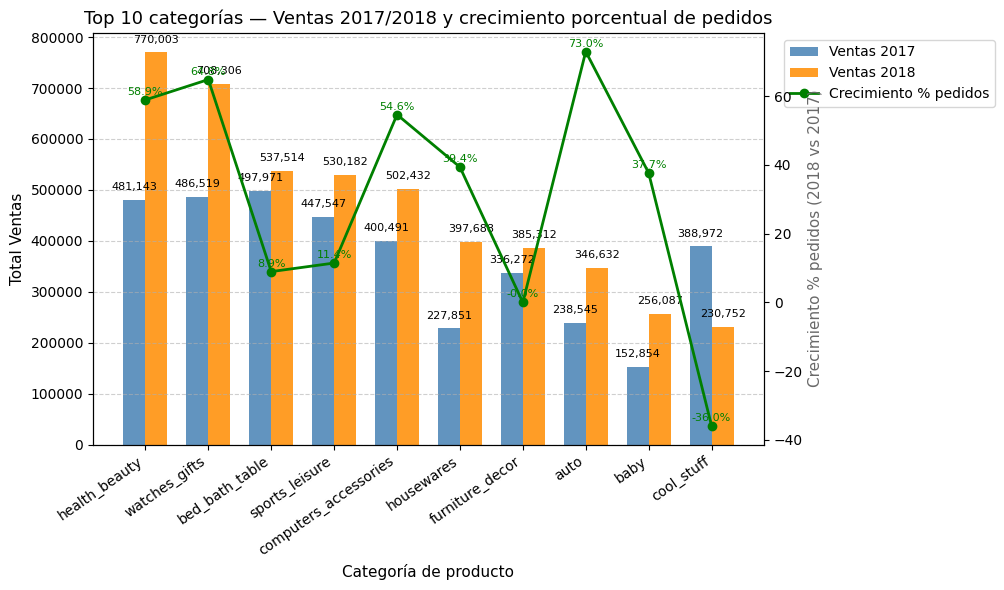

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar las 10 categorías con más ventas en 2018
top10_df = merged_df.sort_values(by="TotalSales_2018", ascending=False).head(10)

# Añadir el crecimiento porcentual de pedidos desde el dataframe growth_df
top10_df = top10_df.merge(
    growth_df[["product_category_name", "orders_growth_pct"]],
    on="product_category_name",
    how="left"
)

# Preparar los datos que se usarán en el gráfico
categories = top10_df["product_category_name"]
sales_2017 = top10_df["TotalSales_2017"]
sales_2018 = top10_df["TotalSales_2018"]
orders_growth = top10_df["orders_growth_pct"]

# Posiciones y ancho de las barras
x = np.arange(len(categories))
width = 0.35

# Crear figura principal con eje de ventas
fig, ax1 = plt.subplots(figsize=(12, 6))
bars1 = ax1.bar(x - width/2, sales_2017, width, label="Ventas 2017", color="steelblue", alpha=0.85)
bars2 = ax1.bar(x + width/2, sales_2018, width, label="Ventas 2018", color="darkorange", alpha=0.85)

# Añadir etiquetas de valor encima de las barras
max_height = max(sales_2017.max(), sales_2018.max())
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            height + (0.02 * max_height),
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Crear un segundo eje para el crecimiento porcentual de pedidos
ax2 = ax1.twinx()
line1, = ax2.plot(x, orders_growth, color="green", marker="o", linewidth=2, label="Crecimiento % pedidos")

# Etiquetas de valor sobre la línea
for i, val in enumerate(orders_growth):
    ax2.text(
        i,
        val + (0.02 * max(orders_growth)),
        f"{val:.1f}%",
        color="green",
        fontsize=8,
        ha="center"
    )

# Personalización del gráfico
ax1.set_title("Top 10 categorías — Ventas 2017/2018 y crecimiento porcentual de pedidos", fontsize=13)
ax1.set_xlabel("Categoría de producto", fontsize=11)
ax1.set_ylabel("Total Ventas", fontsize=11, color="black")
ax2.set_ylabel("Crecimiento % pedidos (2018 vs 2017)", fontsize=11, color="dimgray")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=35, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.6)

# Leyenda combinada (barras + línea)
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc="upper left", bbox_to_anchor=(1.02, 1))

# Ajuste de diseño
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Mostrar gráfico
plt.show()


C:\Users\HY269\AppData\Local\Temp\ipykernel_12176\2416523785.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(categories, rotation=45, ha="right")


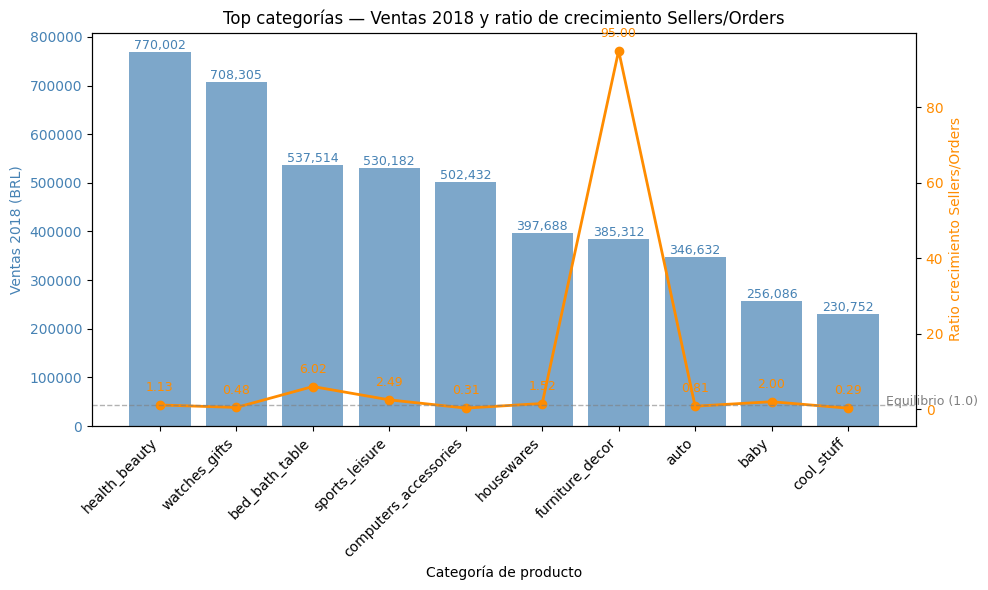

In [22]:
import matplotlib.pyplot as plt

# Ordenar el dataset por ventas de 2018 (de mayor a menor)
plot_df = growth_df.merge(
    merged_df[["product_category_name", "TotalSales_2018"]],
    on="product_category_name",
    how="left"
).sort_values(by="TotalSales_2018", ascending=False)

# Preparar los datos para el gráfico
categories = plot_df["product_category_name"]
sales_2018 = plot_df["TotalSales_2018"]
ratio = plot_df["ratio_growth_sellers_orders"]

# Crear figura con dos ejes: uno para barras y otro para la línea
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfico de barras con las ventas 2018
bars = ax1.bar(categories, sales_2018, color="steelblue", alpha=0.7, label="Ventas 2018")
ax1.set_xlabel("Categoría de producto")
ax1.set_ylabel("Ventas 2018 (BRL)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticklabels(categories, rotation=45, ha="right")

# Etiquetas con los valores de las barras
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="steelblue"
    )

# Segundo eje con la línea del ratio sellers/orders
ax2 = ax1.twinx()
ax2.plot(categories, ratio, color="darkorange", marker="o", linewidth=2, label="Ratio Sellers/Orders")
ax2.set_ylabel("Ratio crecimiento Sellers/Orders", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

# Etiquetas sobre los puntos de la línea
for i, val in enumerate(ratio):
    ax2.text(
        i,
        val + (max(ratio) * 0.03),
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="darkorange"
    )

# Línea de referencia horizontal en 1.0
ax2.axhline(1, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax2.text(len(categories) - 0.5, 1.02, "Equilibrio (1.0)", color="gray", fontsize=9)

# Título y ajuste de diseño
plt.title("Top categorías — Ventas 2018 y ratio de crecimiento Sellers/Orders")
fig.tight_layout()

# Mostrar gráfico
plt.show()


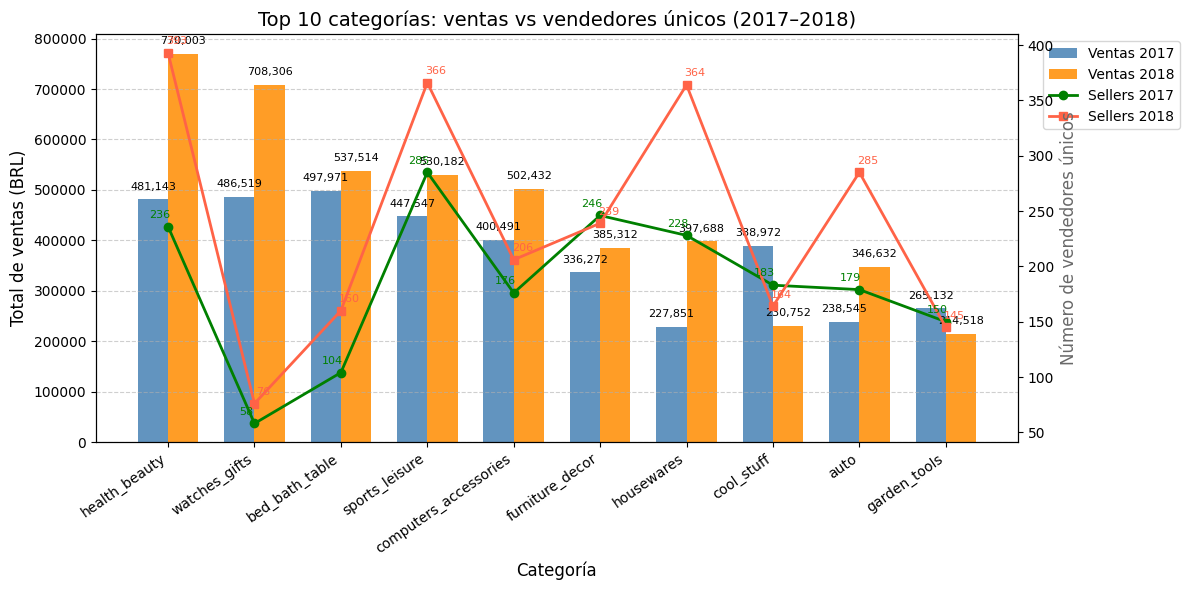

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar las 10 categorías con mayores ventas totales (sumando 2017 y 2018)
top10_cats = (
    merged_df.assign(Total_2017_2018=lambda x: x[["TotalSales_2017", "TotalSales_2018"]].sum(axis=1))
    .sort_values("Total_2017_2018", ascending=False)
    .head(10)
)

# Preparar los datos para el gráfico
categories = top10_cats["product_category_name"].tolist()
sales_2017 = top10_cats["TotalSales_2017"].values
sales_2018 = top10_cats["TotalSales_2018"].values
sellers_2017 = top10_cats["UniqueSellers_2017"].values
sellers_2018 = top10_cats["UniqueSellers_2018"].values

# Posiciones de las barras
x = np.arange(len(categories))
width = 0.35

# Crear figura con el primer eje para las ventas
fig, ax1 = plt.subplots(figsize=(12, 6))
bars1 = ax1.bar(x - width/2, sales_2017, width, label="Ventas 2017", color="steelblue", alpha=0.85)
bars2 = ax1.bar(x + width/2, sales_2018, width, label="Ventas 2018", color="darkorange", alpha=0.85)

# Añadir etiquetas de valor encima de las barras
max_height = max(sales_2017.max(), sales_2018.max())
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height + (0.02 * max_height),
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Segundo eje para mostrar los vendedores únicos
ax2 = ax1.twinx()
line1, = ax2.plot(x, sellers_2017, color="green", marker="o", linewidth=2, label="Sellers 2017")
line2, = ax2.plot(x, sellers_2018, color="tomato", marker="s", linewidth=2, label="Sellers 2018")

# Etiquetas de valor para los puntos de las líneas
for i, val in enumerate(sellers_2017):
    ax2.text(i - 0.1, val + (0.02 * max(sellers_2018)), f"{int(val)}", color="green", fontsize=8, ha="center")
for i, val in enumerate(sellers_2018):
    ax2.text(i + 0.1, val + (0.02 * max(sellers_2018)), f"{int(val)}", color="tomato", fontsize=8, ha="center")

# Personalización del gráfico
ax1.set_title("Top 10 categorías: ventas vs vendedores únicos (2017–2018)", fontsize=14)
ax1.set_xlabel("Categoría", fontsize=12)
ax1.set_ylabel("Total de ventas (BRL)", fontsize=12, color="black")
ax2.set_ylabel("Número de vendedores únicos", fontsize=12, color="dimgray")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=35, ha="right")

# Líneas de referencia horizontales
ax1.grid(axis="y", linestyle="--", alpha=0.6)

# Combinar leyendas de ambos ejes
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc="upper left", bbox_to_anchor=(1.02, 1))

# Ajuste del diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()


C:\Users\HY269\AppData\Local\Temp\ipykernel_12176\1904591183.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_dependientes["product_category_name"], rotation=45, ha="right")


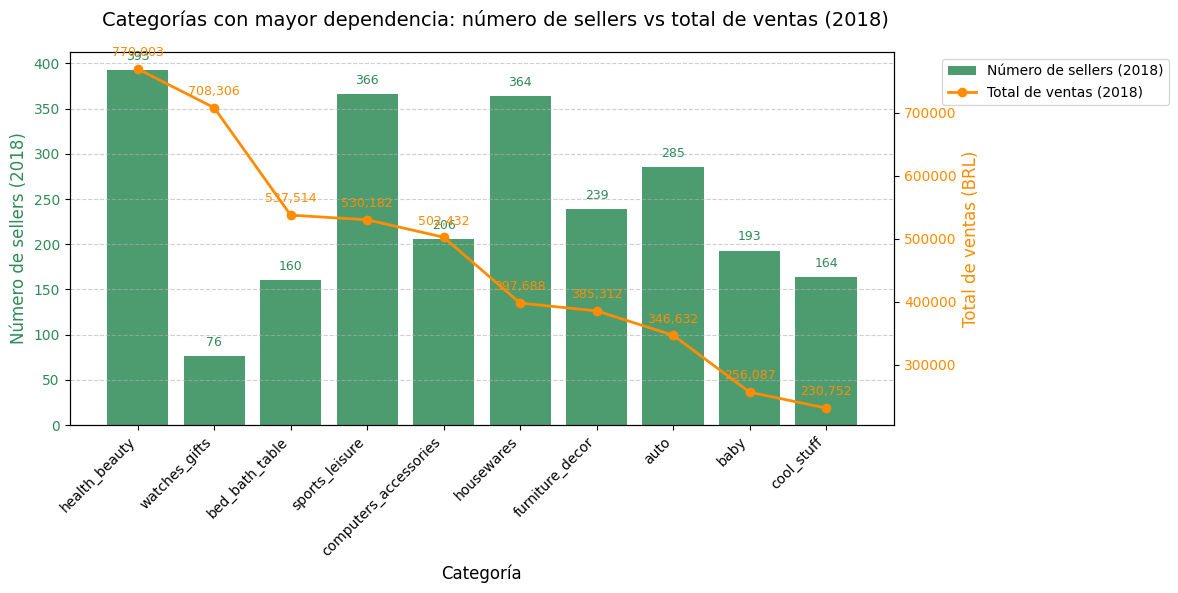

In [24]:
import matplotlib.pyplot as plt

# Seleccionar las 10 categorías con mayores ventas en 2018
top_dependientes = (
    merged_df.sort_values("TotalSales_2018", ascending=False)
    .head(10)
)

# Crear figura y ejes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras con el número de vendedores únicos
bars = ax1.bar(
    top_dependientes["product_category_name"],
    top_dependientes["UniqueSellers_2018"],
    color="seagreen",
    alpha=0.85,
    label="Número de sellers (2018)"
)

# Etiquetas y formato del eje principal
ax1.set_xlabel("Categoría", fontsize=12)
ax1.set_ylabel("Número de sellers (2018)", fontsize=12, color="seagreen")
ax1.tick_params(axis="y", labelcolor="seagreen")
ax1.set_xticklabels(top_dependientes["product_category_name"], rotation=45, ha="right")

# Añadir etiquetas encima de las barras
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + (0.02 * max(top_dependientes["UniqueSellers_2018"])),
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="seagreen"
    )

# Crear un segundo eje para las ventas totales
ax2 = ax1.twinx()
ax2.plot(
    top_dependientes["product_category_name"],
    top_dependientes["TotalSales_2018"],
    color="darkorange",
    marker="o",
    linewidth=2,
    label="Total de ventas (2018)"
)

# Etiquetas del segundo eje
ax2.set_ylabel("Total de ventas (BRL)", fontsize=12, color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

# Mostrar valores en la línea
for i, value in enumerate(top_dependientes["TotalSales_2018"]):
    ax2.text(
        i,
        value + (0.02 * max(top_dependientes["TotalSales_2018"])),
        f"{value:,.0f}",
        color="darkorange",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Título y estilo general
fig.suptitle("Categorías con mayor dependencia: número de sellers vs total de ventas (2018)", fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.6)
fig.tight_layout()

# Combinar las leyendas de ambos ejes
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc="upper left", bbox_to_anchor=(1.05, 1))

# Mostrar gráfico
plt.show()


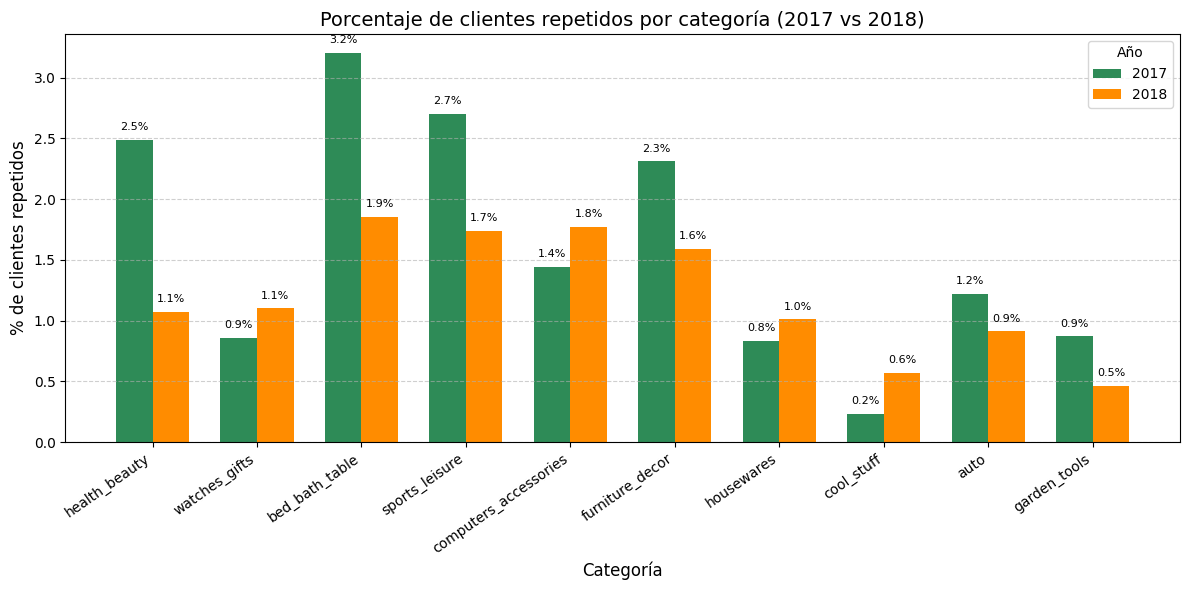

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Convertir columnas a tipo numérico (por si vienen como object)
cols_to_fix = [
    "RepeatCustomers_2017", "Customers_2017",
    "RepeatCustomers_2018", "Customers_2018"
]
merged_df[cols_to_fix] = merged_df[cols_to_fix].apply(pd.to_numeric, errors="coerce")

# Calcular el porcentaje de clientes repetidos
merged_df["RepeatRate_2017"] = (
    (merged_df["RepeatCustomers_2017"] / merged_df["Customers_2017"].replace(0, np.nan)) * 100
).round(2)

merged_df["RepeatRate_2018"] = (
    (merged_df["RepeatCustomers_2018"] / merged_df["Customers_2018"].replace(0, np.nan)) * 100
).round(2)

# Seleccionar las 10 categorías más vendidas (suma de 2017 y 2018)
top10_cats = (
    merged_df.assign(Total_2017_2018=lambda x: x[["TotalSales_2017", "TotalSales_2018"]].sum(axis=1))
    .sort_values("Total_2017_2018", ascending=False)
    .head(10)
)

# Preparar los datos para el gráfico
categories = top10_cats["product_category_name"].tolist()
repeat_2017 = top10_cats["RepeatRate_2017"].values
repeat_2018 = top10_cats["RepeatRate_2018"].values

# Posiciones y ancho de las barras
x = np.arange(len(categories))
width = 0.35

# Crear figura y ejes
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, repeat_2017, width, label="2017", color="seagreen")
bars2 = ax.bar(x + width/2, repeat_2018, width, label="2018", color="darkorange")

# Etiquetas de valor encima de las barras
max_height = np.nanmax([np.nanmax(repeat_2017), np.nanmax(repeat_2018)])
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + (0.02 * max_height),
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Personalización del gráfico
ax.set_title("Porcentaje de clientes repetidos por categoría (2017 vs 2018)", fontsize=14)
ax.set_xlabel("Categoría", fontsize=12)
ax.set_ylabel("% de clientes repetidos", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=35, ha="right")
ax.legend(title="Año")
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Ajuste de diseño
plt.tight_layout()

# Mostrar gráfico
plt.show()


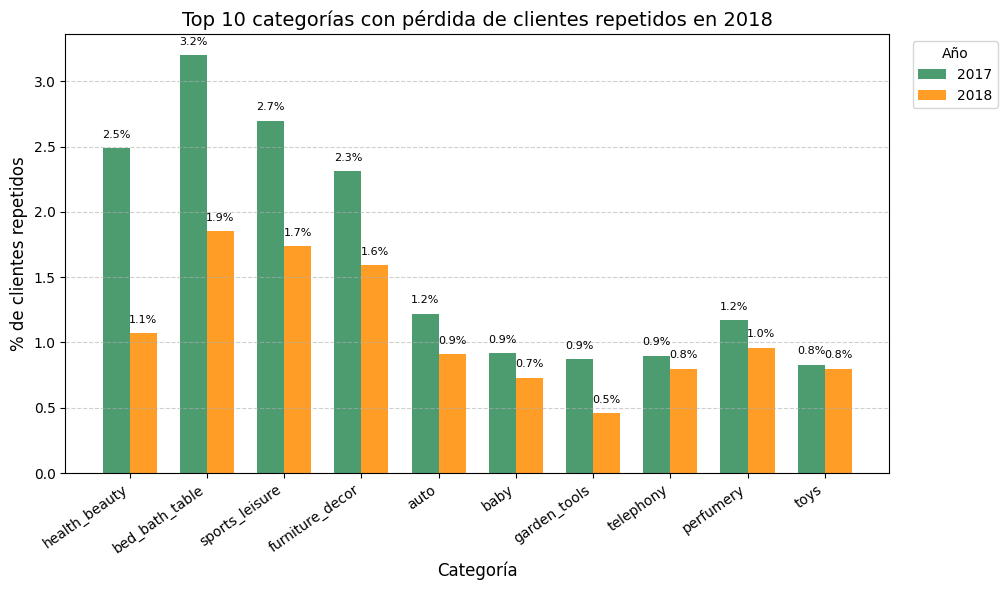

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Asegurar que las columnas numéricas tengan el tipo correcto
cols_to_fix = [
    "RepeatCustomers_2017", "Customers_2017",
    "RepeatCustomers_2018", "Customers_2018"
]
merged_df[cols_to_fix] = merged_df[cols_to_fix].apply(pd.to_numeric, errors="coerce")

# Calcular el porcentaje de clientes repetidos
merged_df["RepeatRate_2017"] = (
    (merged_df["RepeatCustomers_2017"] / merged_df["Customers_2017"].replace(0, np.nan)) * 100
).round(2)

merged_df["RepeatRate_2018"] = (
    (merged_df["RepeatCustomers_2018"] / merged_df["Customers_2018"].replace(0, np.nan)) * 100
).round(2)

# Filtrar las categorías que bajaron su porcentaje de repetición
decay_df = merged_df[merged_df["RepeatRate_2018"] < merged_df["RepeatRate_2017"]].copy()

# Seleccionar las 10 con mayor volumen de ventas en 2018 dentro de las que bajaron
top10_loss = decay_df.sort_values(by="TotalSales_2018", ascending=False).head(10)

# Preparar los datos para el gráfico
categories = top10_loss["product_category_name"].tolist()
repeat_2017 = top10_loss["RepeatRate_2017"].values
repeat_2018 = top10_loss["RepeatRate_2018"].values

# Posiciones y ancho de las barras
x = np.arange(len(categories))
width = 0.35

# Crear figura y gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, repeat_2017, width, label="2017", color="seagreen", alpha=0.85)
bars2 = ax.bar(x + width/2, repeat_2018, width, label="2018", color="darkorange", alpha=0.85)

# Etiquetas de valor sobre las barras
max_height = np.nanmax([np.nanmax(repeat_2017), np.nanmax(repeat_2018)])
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + (0.02 * max_height),
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Personalización del gráfico
ax.set_title("Top 10 categorías con pérdida de clientes repetidos en 2018", fontsize=14)
ax.set_xlabel("Categoría", fontsize=12)
ax.set_ylabel("% de clientes repetidos", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=35, ha="right")
ax.legend(title="Año", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Ajuste de diseño
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Mostrar gráfico
plt.show()


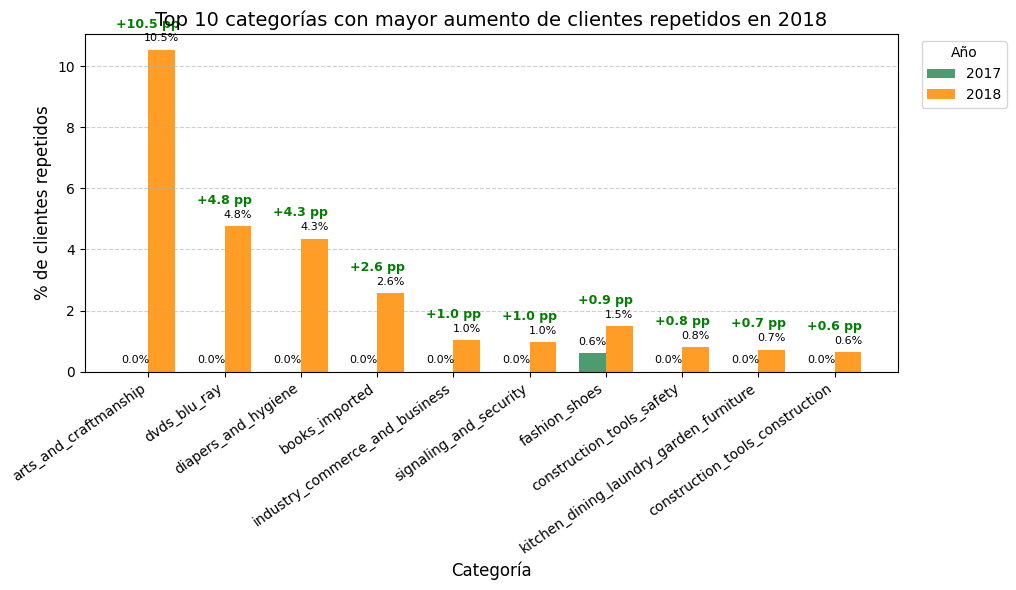

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Asegurar que las columnas necesarias sean numéricas
cols_to_fix = [
    "RepeatCustomers_2017", "Customers_2017",
    "RepeatCustomers_2018", "Customers_2018"
]
merged_df[cols_to_fix] = merged_df[cols_to_fix].apply(pd.to_numeric, errors="coerce")

# Calcular el porcentaje de clientes repetidos
merged_df["RepeatRate_2017"] = (
    (merged_df["RepeatCustomers_2017"] / merged_df["Customers_2017"].replace(0, np.nan)) * 100
).round(2)

merged_df["RepeatRate_2018"] = (
    (merged_df["RepeatCustomers_2018"] / merged_df["Customers_2018"].replace(0, np.nan)) * 100
).round(2)

# Calcular el cambio (delta) entre 2017 y 2018
merged_df["RepeatRate_Delta"] = (merged_df["RepeatRate_2018"] - merged_df["RepeatRate_2017"]).round(2)

# Filtrar las categorías que aumentaron su porcentaje de clientes repetidos
growth_df_repeat = merged_df[merged_df["RepeatRate_Delta"] > 0].copy()

# Seleccionar las 10 con mayor incremento
top10_gain = growth_df_repeat.sort_values(by="RepeatRate_Delta", ascending=False).head(10)

# Preparar los datos para el gráfico
categories = top10_gain["product_category_name"].tolist()
repeat_2017 = top10_gain["RepeatRate_2017"].values
repeat_2018 = top10_gain["RepeatRate_2018"].values
delta = top10_gain["RepeatRate_Delta"].values

# Posiciones y ancho de las barras
x = np.arange(len(categories))
width = 0.35

# Crear la figura
fig, ax = plt.subplots(figsize=(12, 6))

# Dibujar las barras para cada año
bars1 = ax.bar(x - width/2, repeat_2017, width, label="2017", color="seagreen", alpha=0.85)
bars2 = ax.bar(x + width/2, repeat_2018, width, label="2018", color="darkorange", alpha=0.85)

# Etiquetas de valor encima de las barras
max_height = np.nanmax([np.nanmax(repeat_2017), np.nanmax(repeat_2018)])
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + (0.02 * max_height),
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Etiquetas del delta (diferencia positiva) encima de cada grupo de barras
for i, val in enumerate(delta):
    ax.text(
        i,
        max(repeat_2017[i], repeat_2018[i]) + (0.06 * max_height),
        f"+{val:.1f} pp",
        ha="center",
        va="bottom",
        fontsize=9,
        color="green",
        fontweight="bold"
    )

# Personalización del gráfico
ax.set_title("Top 10 categorías con mayor aumento de clientes repetidos en 2018", fontsize=14)
ax.set_xlabel("Categoría", fontsize=12)
ax.set_ylabel("% de clientes repetidos", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=35, ha="right")
ax.legend(title="Año", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Ajuste de diseño
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Mostrar gráfico
plt.show()


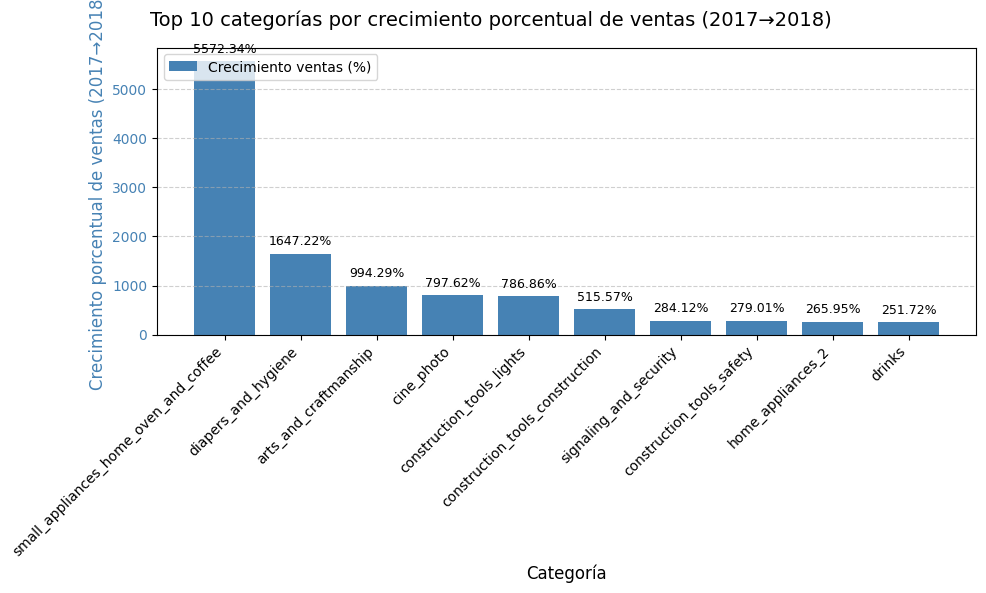

In [30]:
import matplotlib.pyplot as plt

# Seleccionar las 10 categorías con mayor crecimiento porcentual de ventas
top10_delta = merged_df.sort_values("delta_sales_pct_2017_2018", ascending=False).head(10)

# Crear la figura y los ejes del gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar las barras del crecimiento porcentual
bars = ax.bar(
    top10_delta["product_category_name"],
    top10_delta["delta_sales_pct_2017_2018"],
    color="steelblue",
    label="Crecimiento ventas (%)"
)

# Etiquetas y formato de los ejes
ax.set_xlabel("Categoría", fontsize=12)
ax.set_ylabel("Crecimiento porcentual de ventas (2017→2018)", fontsize=12, color="steelblue")
ax.tick_params(axis="y", labelcolor="steelblue")

# Ajustar posiciones del eje X para evitar el warning
ax.set_xticks(range(len(top10_delta["product_category_name"])))
ax.set_xticklabels(top10_delta["product_category_name"], rotation=45, ha="right")

# Añadir etiquetas con los valores encima de cada barra
max_height = max(top10_delta["delta_sales_pct_2017_2018"])
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + (0.02 * max_height),
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

# Título y estilo general del gráfico
fig.suptitle("Top 10 categorías por crecimiento porcentual de ventas (2017→2018)", fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
fig.tight_layout()

# Mostrar la leyenda
ax.legend(loc="upper left")

# Mostrar el gráfico final
plt.show()


In [31]:
# Total de ventas global por año 
totales_por_año = (
    df.groupby("order_year")["price"]
    .sum()
    .reset_index()
    .sort_values("order_year")
)

display(Markdown("### Total de ventas global por año"))
display(totales_por_año)


### Total de ventas global por año

,order_year,price
0,2017,6108492.27
1,2018,7341182.41


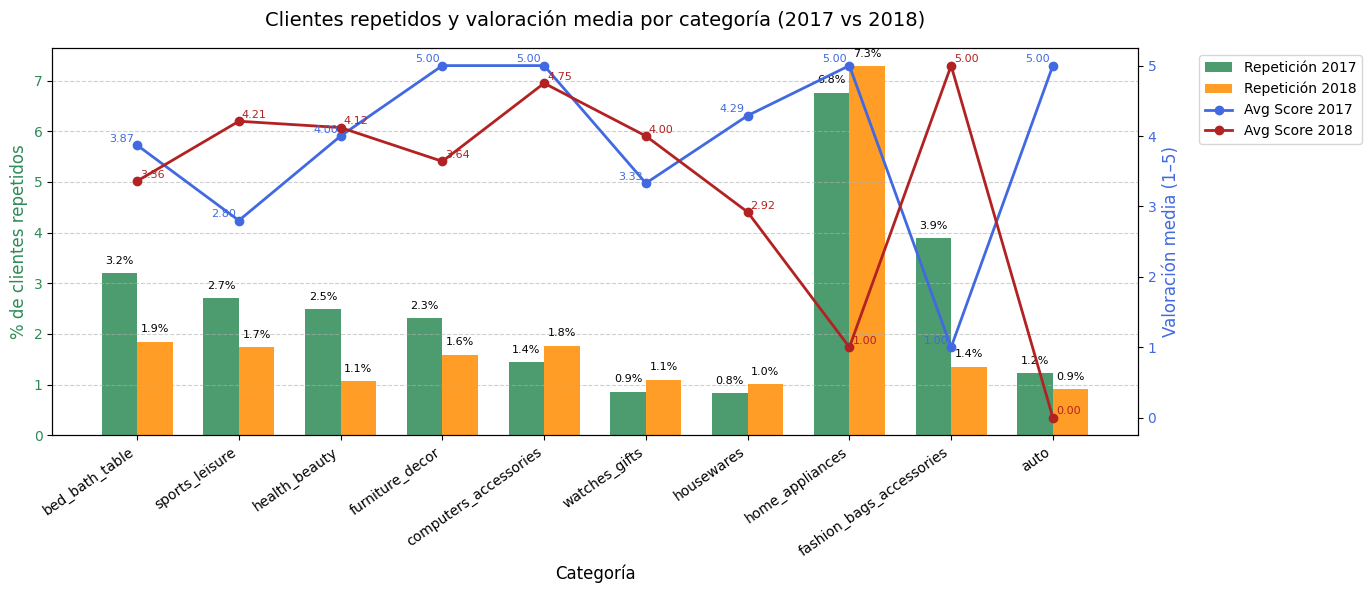

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Asegurar que las columnas numéricas sean del tipo correcto
cols_to_fix = [
    "RepeatCustomers_2017", "Customers_2017",
    "RepeatCustomers_2018", "Customers_2018",
    "avg_score_2017", "avg_score_2018"
]
merged_df[cols_to_fix] = merged_df[cols_to_fix].apply(pd.to_numeric, errors="coerce")

# Calcular el porcentaje de clientes repetidos
merged_df["RepeatRate_2017"] = (
    (merged_df["RepeatCustomers_2017"] / merged_df["Customers_2017"].replace(0, np.nan)) * 100
).round(2)

merged_df["RepeatRate_2018"] = (
    (merged_df["RepeatCustomers_2018"] / merged_df["Customers_2018"].replace(0, np.nan)) * 100
).round(2)

# Seleccionar las 10 categorías con más clientes repetidos (suma de ambos años)
top10_cats = (
    merged_df.assign(TotalRepeat=lambda x: x["RepeatCustomers_2017"] + x["RepeatCustomers_2018"])
    .sort_values("TotalRepeat", ascending=False)
    .head(10)
)

# Preparar los datos para el gráfico
categories = top10_cats["product_category_name"].tolist()
repeat_2017 = top10_cats["RepeatRate_2017"].values
repeat_2018 = top10_cats["RepeatRate_2018"].values
avg_score_2017 = top10_cats["avg_score_2017"].values
avg_score_2018 = top10_cats["avg_score_2018"].values

# Posiciones y ancho de las barras
x = np.arange(len(categories))
width = 0.35

# Crear la figura y el primer eje (porcentaje de clientes repetidos)
fig, ax1 = plt.subplots(figsize=(12, 6))
bars1 = ax1.bar(x - width/2, repeat_2017, width, label="Repetición 2017", color="seagreen", alpha=0.85)
bars2 = ax1.bar(x + width/2, repeat_2018, width, label="Repetición 2018", color="darkorange", alpha=0.85)

# Añadir etiquetas de valor sobre las barras
max_height = np.nanmax([np.nanmax(repeat_2017), np.nanmax(repeat_2018)])
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height + (0.02 * max_height),
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Configuración del eje izquierdo
ax1.set_xlabel("Categoría", fontsize=12)
ax1.set_ylabel("% de clientes repetidos", fontsize=12, color="seagreen")
ax1.tick_params(axis="y", labelcolor="seagreen")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=35, ha="right")

# Segundo eje para las valoraciones medias
ax2 = ax1.twinx()
ax2.plot(x, avg_score_2017, color="royalblue", marker="o", linewidth=2, label="Avg Score 2017")
ax2.plot(x, avg_score_2018, color="firebrick", marker="o", linewidth=2, label="Avg Score 2018")

# Añadir etiquetas numéricas a las líneas
for i, (v2017, v2018) in enumerate(zip(avg_score_2017, avg_score_2018)):
    ax2.text(x[i] - 0.15, v2017 + 0.02, f"{v2017:.2f}", color="royalblue", ha="center", va="bottom", fontsize=8)
    ax2.text(x[i] + 0.15, v2018 + 0.02, f"{v2018:.2f}", color="firebrick", ha="center", va="bottom", fontsize=8)

# Configuración del eje derecho
ax2.set_ylabel("Valoración media (1–5)", fontsize=12, color="royalblue")
ax2.tick_params(axis="y", labelcolor="royalblue")

# Estilo general del gráfico
fig.suptitle("Clientes repetidos y valoración media por categoría (2017 vs 2018)", fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.6)
fig.tight_layout()

# Combinar las leyendas de ambos ejes
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc="upper left", bbox_to_anchor=(1.05, 1))

# Mostrar el gráfico
plt.show()


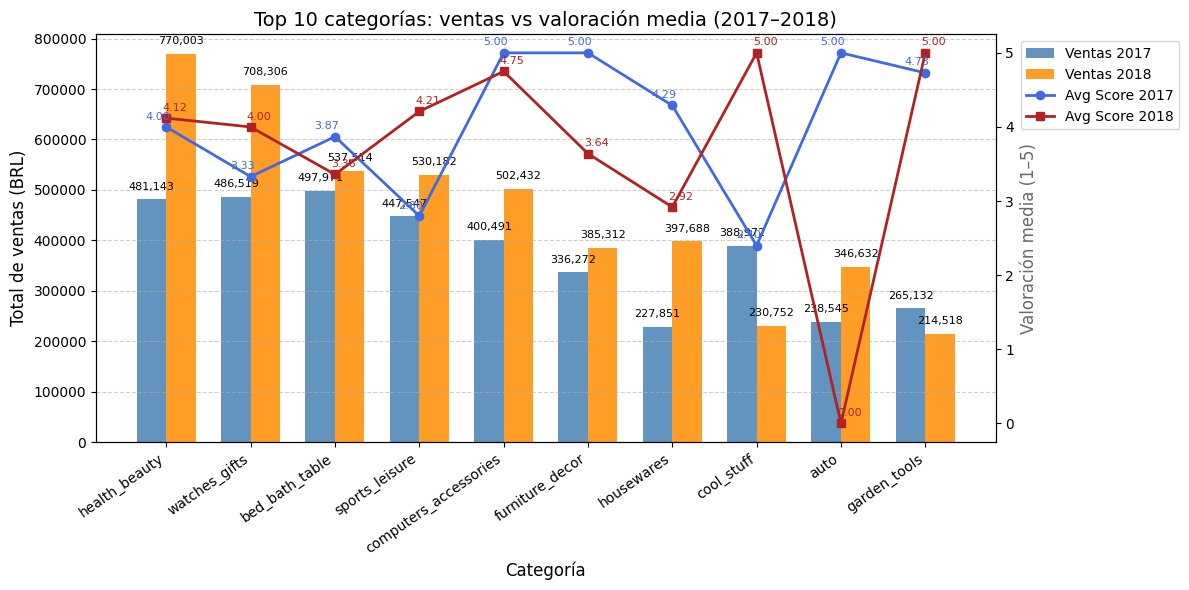

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Asegurar que las columnas numéricas tengan el tipo correcto
cols_to_fix = [
    "TotalSales_2017", "TotalSales_2018",
    "avg_score_2017", "avg_score_2018"
]
merged_df[cols_to_fix] = merged_df[cols_to_fix].apply(pd.to_numeric, errors="coerce")

# Seleccionar las 10 categorías con mayores ventas totales (sumando 2017 y 2018)
top10_cats = (
    merged_df.assign(Total_2017_2018=lambda x: x[["TotalSales_2017", "TotalSales_2018"]].sum(axis=1))
    .sort_values("Total_2017_2018", ascending=False)
    .head(10)
)

# Preparar los datos para el gráfico
categories = top10_cats["product_category_name"].tolist()
sales_2017 = top10_cats["TotalSales_2017"].values
sales_2018 = top10_cats["TotalSales_2018"].values
score_2017 = top10_cats["avg_score_2017"].values
score_2018 = top10_cats["avg_score_2018"].values

# Posiciones y ancho de las barras
x = np.arange(len(categories))
width = 0.35

# Crear figura con el primer eje (ventas)
fig, ax1 = plt.subplots(figsize=(12, 6))
bars1 = ax1.bar(x - width/2, sales_2017, width, label="Ventas 2017", color="steelblue", alpha=0.85)
bars2 = ax1.bar(x + width/2, sales_2018, width, label="Ventas 2018", color="darkorange", alpha=0.85)

# Añadir etiquetas con los valores de las barras
max_height = np.nanmax([np.nanmax(sales_2017), np.nanmax(sales_2018)])
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height + (0.02 * max_height),
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Crear segundo eje con las valoraciones medias
ax2 = ax1.twinx()
ax2.plot(x, score_2017, color="royalblue", marker="o", linewidth=2, label="Avg Score 2017")
ax2.plot(x, score_2018, color="firebrick", marker="s", linewidth=2, label="Avg Score 2018")

# Etiquetas numéricas sobre las líneas
max_score = np.nanmax([np.nanmax(score_2017), np.nanmax(score_2018)])
for i, val in enumerate(score_2017):
    ax2.text(i - 0.1, val + (0.02 * max_score), f"{val:.2f}", color="royalblue", fontsize=8, ha="center")
for i, val in enumerate(score_2018):
    ax2.text(i + 0.1, val + (0.02 * max_score), f"{val:.2f}", color="firebrick", fontsize=8, ha="center")

# Personalización general
ax1.set_title("Top 10 categorías: ventas vs valoración media (2017–2018)", fontsize=14)
ax1.set_xlabel("Categoría", fontsize=12)
ax1.set_ylabel("Total de ventas (BRL)", fontsize=12, color="black")
ax2.set_ylabel("Valoración media (1–5)", fontsize=12, color="dimgray")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=35, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.6)

# Combinar leyendas de ambos ejes
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc="upper left", bbox_to_anchor=(1.02, 1))

# Ajuste del diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()


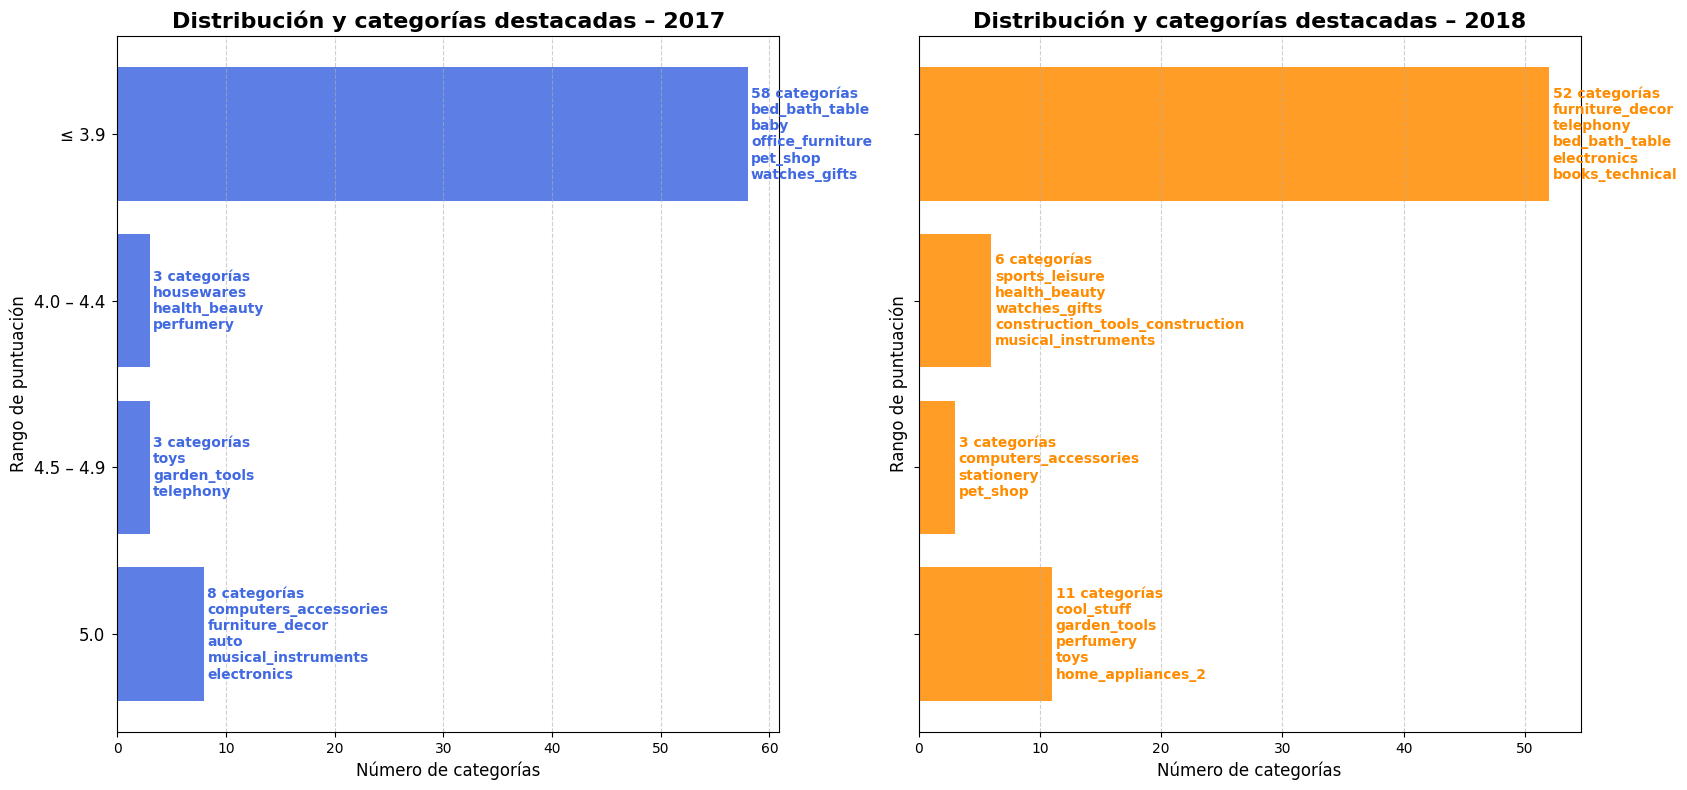

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegurar que los nombres de categoría no tengan valores nulos
merged_df["product_category_name"] = merged_df["product_category_name"].fillna("Sin categoría").astype(str)

# Definir los grupos de puntuación (de menor a mayor)
bins = [0, 3.9, 4.4, 4.9, 5.0]
labels = ["≤ 3.9", "4.0 – 4.4", "4.5 – 4.9", "5.0"]

# Crear columnas con el grupo de puntuación para cada año
merged_df["score_group_2017"] = pd.cut(
    merged_df["avg_score_2017"], bins=bins, labels=labels, include_lowest=True
)
merged_df["score_group_2018"] = pd.cut(
    merged_df["avg_score_2018"], bins=bins, labels=labels, include_lowest=True
)

# Función auxiliar para generar el resumen por grupo
def resumen_por_grupo(df, col_score, col_group):
    resumen = []
    for group in labels[::-1]:  # Mostrar primero los de mayor puntuación
        subset = df[df[col_group] == group].sort_values(col_score, ascending=False)
        categorias = subset["product_category_name"].head(5).tolist()
        texto = "\n".join(categorias) if categorias else "-"
        resumen.append({
            "Rango": group,
            "Categorías": texto,
            "Cantidad": len(subset)
        })
    return pd.DataFrame(resumen)

# Crear los resúmenes para 2017 y 2018
resumen_2017 = resumen_por_grupo(merged_df, "avg_score_2017", "score_group_2017")
resumen_2018 = resumen_por_grupo(merged_df, "avg_score_2018", "score_group_2018")

# Crear los gráficos uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(17, 8), sharey=True)

# Gráfico 2017
axes[0].barh(resumen_2017["Rango"], resumen_2017["Cantidad"], color="royalblue", alpha=0.85)
axes[0].set_title("Distribución y categorías destacadas – 2017", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Número de categorías", fontsize=12)
axes[0].set_ylabel("Rango de puntuación", fontsize=12)
axes[0].grid(axis="x", linestyle="--", alpha=0.6)
axes[0].tick_params(axis="y", labelsize=12, pad=5)

# Mostrar etiquetas de texto junto a las barras
for i, row in resumen_2017.iterrows():
    axes[0].text(
        row["Cantidad"] + 0.3, i,
        f"{row['Cantidad']} categorías\n{row['Categorías']}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="royalblue"
    )

# Gráfico 2018
axes[1].barh(resumen_2018["Rango"], resumen_2018["Cantidad"], color="darkorange", alpha=0.85)
axes[1].set_title("Distribución y categorías destacadas – 2018", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Número de categorías", fontsize=12)
axes[1].set_ylabel("Rango de puntuación", fontsize=12)
axes[1].grid(axis="x", linestyle="--", alpha=0.6)
axes[1].tick_params(axis="y", labelsize=12, pad=5)

# Mostrar etiquetas en el gráfico 2018
for i, row in resumen_2018.iterrows():
    axes[1].text(
        row["Cantidad"] + 0.3, i,
        f"{row['Cantidad']} categorías\n{row['Categorías']}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="darkorange"
    )

# Evitar el warning de set_yticklabels
axes[0].set_yticks(range(len(resumen_2017)))
axes[1].set_yticks(range(len(resumen_2018)))
axes[0].set_yticklabels(resumen_2017["Rango"])
axes[1].set_yticklabels(resumen_2018["Rango"])

# Ajustar el diseño y mostrar el gráfico final
plt.tight_layout()
plt.show()
